# Gate 0 : Ingestion/Load Data

In [ ]:
##### ▶️ Objetivo :
# Paso EDA / medición: Paso 0 — carga e ingesta con 
# pd.read_csv() (dtype + na_values + keep_default_na).
# Se puede hacer la ingesta con un pipeline de ingestión de datos ?

In [49]:
import os
print("Directorio actual:", os.getcwd())
print("Archivos aqui:", [f for f in os.listdir(".") if f.endswith(".csv")])
import sys
sys.path.insert(0, "/home/jovyan/work")   # que Python vea tus .py de work/

Directorio actual: /home/jovyan
Archivos aqui: []


In [46]:
import pandas as pd
import numpy as np
df = pd.read_csv(
    "/home/jovyan/work/U4_04_train.csv"
)


In [ ]:
df2 = pd.read_csv(
    "/home/jovyan/work/U4_04_train.csv",        # debe estar en work/ junto al notebook
    dtype={
        "PassengerId": "int",
        "Survived": "int",
        "Pclass": "int",
        "Sex": "category",
        "Embarked": "category",
    },
    # blancos vacios ("") deben contar como nulos (Cabin/Embarked los traen)
    na_values=["", " "],
    # Activamos los nulos de pandas (NaN) para que se detecten en el DataFrame
    keep_default_na=True,
)

# Gate 1: Structure and Context

In [ ]:
##### ▶️ Objetivo:
# entender la forma y granularidad. 
# ¿Qué representa una fila? 
# ¿Cuántas filas/columnas? 
# ¿Qué es cada columna (ID, categórica, numérica, tiempo)?
# ¿Puedo obtener el dato, de forma durable y a la frecuencia necesaria?

In [27]:
# Imprimimos la forma del DataFrame y las columnas
print("Cargado:", df.shape, )
# Imprimimos las columnas del DataFrame
print("columnas:", df.columns.tolist())
# Imprimimos las primeras filas del DataFrame
df.head()

Cargado: (891, 12)
columnas: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
##### 👻 Comentarios sobre el dataset que se puede apreciar en la salida de las celdas anteriores:
# - El dataset tiene 891 filas y 12 columnas.

# - El dataset contiene información sobre los pasajeros del Titanic, incluyendo si sobrevivieron o no.
# - Las columnas incluyen información demográfica y de viaje, como edad, sexo, clase de pasajero, etc.
# - La columna 'Survived' es la variable objetivo que indica si el pasajero sobrevivió (1) o no (0).
# - La columna 'PassengerId' es un identificador único para cada pasajero.
# - La columna 'Pclass' indica la clase del pasajero (1, 2 o 3).
# - La columna 'Sex' indica el sexo del pasajero
# - La columna 'Age' indica la edad del pasajero.
# - La columna 'SibSp' indica el número de hermanos/esposos a bordo.
# - La columna 'Parch' indica el número de padres/hijos a bordo.
# - La columna 'Ticket' indica el número de ticket del pasajero.
# - La columna 'Fare' indica la tarifa pagada por el pasajero.
# - La columna 'Cabin' indica la cabina del pasajero.
# - La columna 'Embarked' indica el puerto de embarque del pasajero (C = Cherbourg, Q = Queenstown, S = Southampton).

In [25]:
# Imprimimos la forma del DataFrame y el tipo las columnas
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
##### 👻 Comentarios sobre el dataset que se puede apreciar en la salida de las celdas anteriores:

# - El dataset tiene 891 filas y 12 columnas.
# - Podemos observar que algunas columnas tienen valores nulos, como 'Age', 'Cabin' y 'Embarked'.
# - La columna 'Cabin' tiene muchos valores nulos, lo que podría indicar que no es muy útil para el análisis.
# - La columna 'Age' tiene 177 valores nulos, lo que podría ser un problema si queremos usarla como variable predictiva.
# - La columna 'Embarked' tiene 2 valores nulos, lo que podría ser un problema si queremos usarla como variable predictiva

In [33]:
# Cardinalidad  : Imprimimos el número de valores únicos por columna.
# El tratamiento de una columna sale de cruzar tres cosas: 
# tipo de dato + cardinalidad + % de nulos. 
# La cardinalidad es la pista más fuerte de las tres, pero no manda sola.

print("\n--- Cardinalidad (valores unicos por columna) ---")
df.nunique().sort_values()


--- Cardinalidad (valores unicos por columna) ---


Survived         2
Sex              2
Pclass           3
Embarked         3
Parch            7
SibSp            7
Age             88
Cabin          147
Fare           248
Ticket         681
PassengerId    891
Name           891
dtype: int64

In [44]:

resumen = pd.DataFrame({
    "unicos":    df.nunique(),
    "no_nulos":  df.notna().sum(),
    "nulos":     df.isna().sum(),
})
resumen["% nulos"] = (resumen["nulos"] / len(df) * 100).round(1)
print(resumen.sort_values("% nulos", ascending=False))


             unicos  no_nulos  nulos  % nulos
Cabin           147       204    687     77.1
Age              88       714    177     19.9
Embarked          3       889      2      0.2
PassengerId     891       891      0      0.0
Name            891       891      0      0.0
Pclass            3       891      0      0.0
Survived          2       891      0      0.0
Sex               2       891      0      0.0
Parch             7       891      0      0.0
SibSp             7       891      0      0.0
Fare            248       891      0      0.0
Ticket          681       891      0      0.0


In [92]:
# Obtenemos una descripcion general de la Cardinalidad y Nulos del DataFrame
from work.tool_clasificar_features import tabla_features, comentario_features

tabla_features(df, target="Survived")        # tabla con el veredicto
print(comentario_features(df, target="Survived"))  # bloque para pegar como comentario

# ============================================================
#  DICCIONARIO DE FEATURES (auto-generado)
#  usar: SI = usar | NO = descartar cruda | CON TRABAJO = feature eng.
# ------------------------------------------------------------
#  PassengerId  NO (cruda)   cardinalidad ~= filas -> feature engineering o descartar
#  Survived     -            variable objetivo (lo que se predice)
#  Pclass       SI           one-hot / ordinal
#  Name         NO (cruda)   cardinalidad ~= filas -> feature engineering o descartar
#  Sex          SI           encoding a 0/1
#  Age          SI           escalar si el modelo lo requiere; imputar 177 nulos (19.9%)
#  SibSp        SI           one-hot / ordinal
#  Parch        SI           one-hot / ordinal
#  Ticket       CON TRABAJO  encoding especial (target/hashing) o extraer sub-feature
#  Fare         SI           escalar si el modelo lo requiere
#  Cabin        CON TRABAJO  77% nulos -> bandera tiene/no, o descartar
#  Embarked     SI         

In [ ]:
# 🚪 CONCLUSION > 🟢 Gate 1 — Accesibilidad y flujo del dato

# (DRL Banda C · CRISP-DM Data Understanding)

# Pregunta: ¿Puedo obtener el dato, de forma durable y a la frecuencia necesaria?
# Paso EDA / medición: Paso 0 — carga e ingesta con pd.read_csv() (dtype + na_values + keep_default_na).
# Núcleo cuantitativo: formato/ingesta; ¿carga sin corromper tipos?
# Evidencia:
#       El CSV cargó a (891, 12) sin errores.
# Encoding  ASCII limpio; sin corrupción de tipos (tipos forzados y verificados).
# 0 problemas de ingesta (ni encoding, ni separadores, ni columnas desplazadas).
# Matiz: es un export único (one-off), no un pipeline en vivo. Según GateGoNoGo_V3.md, un one-off manual normalmente califica CONDITIONAL.
# Veredicto: GO. Al ser un dataset tipo benchmark académico (no un activo de planta que instrumentar hacia adelante), la accesibilidad es total y estable. Mismo criterio con que el apéndice de GateGoNoGo_V3.md califica al CMAPSS como GO.
# Condición / dueño / plazo: ninguna. Cerrado.

#Conclusión en una línea: el dato entra limpio y completo; la ingesta no es un riesgo para este proyecto.

# Gate 2 — Data quality and Validations


In [ ]:
##### ▶️ Objetivo :
# Cruce EDA: Paso 1 (estructura) + Paso 2 (calidad) (DRL Banda B).
# Núcleo cuantitativo: % de nulos por columna, # duplicados, # valores imposibles, # columnas
# constantes, y picos en los bordes (capping).
# Bloque A — Estructura (Paso 1)
# 1. df.shape — dimensiones ✓ (ya lo vimos: 891×12)
# 2. df.info() — tipos + no-nulos + memoria ✓
# 3. df.dtypes — tipos ✓
# 4. df.head() / df.sample() — inspección ✓
# 5. df.nunique() — cardinalidad (IDs y constantes) ✓ (lo discutimos a fondo)

# Bloque B — Calidad (Paso 2) ← aquí hacemos el modo guiado, una por una
# 6. df.isnull().sum() — nulos
# 7. df.duplicated().sum() — duplicados
# 8. df.columns[df.nunique() <= 1] — constantes
# 9. df.describe() — rangos imposibles MIN , MAX
# 10. df['col'].value_counts() — capping / higiene de categóricas
# 11. scipy.stats.skew() — sesgo (guía transformación log)
# 12. missingno — matrix, bar, heatmap, dendrogram

In [ ]:
##### 🔶  F6 : Validamos los nulos 
#####     Funcion : df.isnull().sum()

# los nulos rompen casi cualquier modelo (sklearn lanza error si le pasas NaN).
# Y el porcentaje de nulos es lo que decide si una columna se rescata o se descarta.
# df.isnull() devuelve un DataFrame del mismo tamaño, pero de True/False: 
#               True donde el valor es nulo (NaN), False donde hay dato. (df.isna() es exactamente lo mismo, un alias.)
# .sum() suma por columna. Como True vale 1 y False vale 0, la suma = número de nulos por columna.

In [54]:
# conteo de nulos por columna
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [57]:
# el mismo dato en %, que es lo que de verdad guia la decision
(df.isnull().mean() * 100).round(1).sort_values(ascending=False)

Cabin          77.1
Age            19.9
Embarked        0.2
PassengerId     0.0
Name            0.0
Pclass          0.0
Survived        0.0
Sex             0.0
Parch           0.0
SibSp           0.0
Fare            0.0
Ticket          0.0
dtype: float64

In [ ]:
##### 👻 Comentarios sobre el dataset que se puede apreciar en la salida de las celdas anteriores:
# isnull().sum() cuenta los huecos; 
# isnull().mean()*100 te dice qué tan grave es cada uno; 
#           y el % define el tratamiento — trivial, imputar con cuidado, o descartar/convertir.

##### 🔷 En base a los campos nulos , vale la pena rescatarlo ?
# 0.- ¿Cuánto falta? (% de nulos) R= Poco (<5%) o Mucho (>~40-60%)
# 1.- Se imputa (se rellena)? R= Depende  
# 2.- Se convierte en una senial ? R= Si o NO
# 3.- Esta relacionada con lo que se quiere predecir ? R= Si o NO . 
# Ver documento de Gate2_valoresnulos.md para mas detalles.

# Campo con nulos
#      │
#  [0] ¿Cuánto falta? (% de nulos)
#      ├── poco (~<5%) ──► imputar directo (moda/mediana). FIN.
#      └── mucho (>~40-60%)
#              │
#          [1] ¿Está relacionada con el target?   ◄── esta manda
#              ├── NO ──► descartar la columna. FIN.
#              └── SÍ
#                    │
#                [2] ¿Se puede imputar con sentido?
#                    ├── SÍ ──► imputar (con cuidado, por grupo)
#                    └── NO (inventarías demasiado) ──► convertir en señal (bandera 0/1)

In [56]:
# el mismo dato en %, que es lo que de verdad guia la decision

resumen = pd.DataFrame({
    "no_nulos":  df.notna().sum(),
    "nulos":     df.isna().sum(),
})
resumen["% nulos"] = (resumen["nulos"] / len(df) * 100).round(1)
print(resumen.sort_values("% nulos", ascending=False))

             no_nulos  nulos  % nulos
Cabin             204    687     77.1
Age               714    177     19.9
Embarked          889      2      0.2
PassengerId       891      0      0.0
Name              891      0      0.0
Pclass            891      0      0.0
Survived          891      0      0.0
Sex               891      0      0.0
Parch             891      0      0.0
SibSp             891      0      0.0
Fare              891      0      0.0
Ticket            891      0      0.0


In [62]:

# ¿La ausencia de Cabin predice supervivencia?
# 1) creamos la bandera: 1 = tenia cabina registrada, 0 = no
df_cabina = df.copy()
df_cabina["tiene_cabina"] = df_cabina["Cabin"].notna().astype(int)

# 2) tasa de supervivencia segun tenga o no cabina
df_cabina.groupby("tiene_cabina")["Survived"].mean().round(3)

# 👁️ Qué hace cada parte
# df["Cabin"].notna()           → Serie de True/False: True donde Cabin tiene dato, False donde es nulo. 
#                                   (Es el opuesto de isna().)
# .astype(int)                  → convierte True→1 y False→0. Ya tienes la bandera tiene_cabina.
# .groupby("tiene_cabina")      → parte el dataset en dos montones: los que tienen cabina (1) y los que no (0).
# ["Survived"].mean()           → aquí está el truco elegante: como Survived es 0/1, su promedio ES la proporción de sobrevivientes. 
#                                 Promediar una columna de 0s y 1s = fracción de 1s = tasa de supervivencia. (Mismo principio que usamos con los nulos: media de binario = proporción.)
# .round(3)                     → redondea a 3 decimales para leerlo cómodo.

tiene_cabina
0    0.300
1    0.667
Name: Survived, dtype: float64

In [63]:
# ¿Quien tiene cabina registrada? Casi solo 1a clase
pd.crosstab(df_cabina["Pclass"], 
df_cabina["tiene_cabina"], normalize="index").round(2)

tiene_cabina,0,1
Pclass,,
1,0.19,0.81
2,0.91,0.09
3,0.98,0.02


In [ ]:
##### 👻 Comentarios sobre el dataset que se puede apreciar en la salida de las celdas anteriores:
# Es decir: sin cabina → 30.0% sobrevivió · con cabina → 66.7% sobrevivió. Eso confirma la tabla.
# 1ª clase la gran mayoría tiene cabina (≈0.81 en la columna 1) y en 3ª casi nadie (≈0.02). Eso demuestra que

In [ ]:
##### 🔶  F7 : Validamos las filas duplicadas 
#####     Funcion : df.duplicate().sum()

# df.duplicated() recorre las filas de arriba abajo y devuelve una Serie de True/False, una por fila. Marca True si esa fila es idéntica a otra que ya vio antes (mismos valores en todas las columnas). La primera aparición se queda en False; solo las repeticiones se marcan True.
# .sum() cuenta los True (True=1, False=0) → número de filas duplicadas

In [66]:
# 1) filas duplicadas completas (idénticas en TODAS las columnas)
df.duplicated().sum()

np.int64(0)

In [67]:
# 2) ¿hay PassengerId repetidos? deberia ser 0 (es el identificador unico)
df["PassengerId"].duplicated().sum()

np.int64(0)

In [ ]:
###### 👻 Comentarios sobre el dataset que se puede apreciar en la salida de las celdas anteriores
# Filas duplicadas completas: np.int64(0) → no hay ni una sola fila repetida. Cada pasajero es único.
# PassengerId duplicados: np.int64(0) → el identificador es limpio, sin repetidos. Es un ID de verdad.:

In [ ]:
##### 🔶  F8 : Validamos las Columnas constantes (DETECTAR VARIANZA CERO)
#####     Funcion : df.columns[df.nunique() <= 1]
#####     Objetivo : detectar columnas que tienen el mismo valor en todas las columnas 
#####                esto genera Varianza Cero -> Ruido/Costo al modelo, se pueden eliminar del dataset.
##### 

# Qué hace, por dentro (se lee de adentro hacia afuera):

# df.nunique() → cuántos valores distintos tiene cada columna (la cardinalidad que ya conoces).
# df.nunique() <= 1 → una Serie de True/False: True en las columnas que tienen 1 o 0 valores distintos (es decir, todas sus filas son el mismo valor, o está toda vacía).
# df.columns[...] → usa esa máscara de True/False para filtrar los nombres de columna, devolviéndote solo los de las constantes.

# 👁️ OJO IMPORTANTE: VarianceThreshold (Seleccionar Features )VS Varianza 0 (Eliminar Columnas que hacen ruido)
# Lo del Gate 2 es calidad: "esta columna está muerta (varianza 0), no debería ni estar aquí". Es limpieza. Eso ya lo cubrimos.
# Lo de VarianceThreshold es selección: "de las columnas vivas, ¿cuáles aportan tan poco que mejor las quito antes de entrenar?". Es optimización del modelo. Eso es después.
#                                        esto se hace en el modelo de selección de features, no en el de limpieza de datos.

In [69]:
# lista de columnas constantes (sin señal -> candidatas a eliminar)
constantes = df.columns[df.nunique() <= 1].tolist()
constantes

[]

In [70]:
df_mexico = df.copy()
df_mexico["pais"] = 'Mexico'


In [75]:
df_mexico.head()
columnas_constantes = df_mexico.columns[df_mexico.nunique() <= 1].tolist()
columnas_constantes


['pais']

In [76]:
# varianza de las columnas numericas del experimento
df_mexico.var(numeric_only=True)

PassengerId    66231.000000
Survived           0.236772
Pclass             0.699015
Age              211.019125
SibSp              1.216043
Parch              0.649728
Fare            2469.436846
dtype: float64

In [77]:
# la varianza de una constante es 0; comparala con una que si varia
import numpy as np
print("varianza de pais (constante):", np.var(df_mexico["pais"].astype("category").cat.codes))
print("varianza de Age (varia):     ", round(df["Age"].var(), 2))
print("varianza de Fare (varia):    ", round(df["Fare"].var(), 2))

varianza de pais (constante): 0.0
varianza de Age (varia):      211.02
varianza de Fare (varia):     2469.44


In [ ]:
##### 🔶  F9 : Rangos de valore posibles 
#####     Funcion : df.describe()
#####     Objetivo : Resumen estadístico de las columnas numéricas del DataFrame
#####                validar los rangos de valores MIN y MAX
#####     NOTA: Te dice qué INVESTIGAR. es contestas estas preguntas. 
#####           - ¿Es raro?
#####           - ¿puede existir esto en la realidad?
#####           - ¿Que se hace?

# Veo un valor raro (MIN,MAX)
#      │
#      ▼
# ¿Es físicamente imposible / un error de captura?
#      ├── SÍ  → es un error o centinela → se corrige o se elimina
#      └── NO  → es un dato real inusual → SE QUEDA (y a veces es oro)

# df.describe() calcula, solo para las columnas numéricas, un resumen estadístico de cada una:
# | `count` | cuántos valores no nulos hay |
# | `mean` | promedio |
# | `std` | desviación estándar (qué tan dispersos están — la raíz de la varianza que vimos) |
# | `min` | el valor más chico |
# | `25%` / `50%` / `75%` | percentiles (el 50 % es la mediana) |
# | `max` | el valor más grande |

# 👁️ NOTA : el MAX y MIN > Nos ayudaran para detectar CAPPINGS con la funcion value_counts()

In [79]:
# resumen estadistico de las numericas (redondeado para leer facil)
df.describe().round(2)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.00,891.00,891.00,714.00,891.00,891.00,891.00
mean,446.00,0.38,2.31,29.70,0.52,0.38,32.20
std,257.35,0.49,0.84,14.53,1.10,0.81,49.69
min,1.00,0.00,1.00,0.42,0.00,0.00,0.00
25%,223.50,0.00,2.00,20.12,0.00,0.00,7.91
50%,446.00,0.00,3.00,28.00,0.00,0.00,14.45
75%,668.50,1.00,3.00,38.00,1.00,0.00,31.00
max,891.00,1.00,3.00,80.00,8.00,6.00,512.33


In [80]:
# solo los extremos, que es lo que caza imposibles
df.describe().loc[["min", "max"]].round(2)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
min,1.0,0.0,1.0,0.42,0.0,0.0,0.00
max,891.0,1.0,3.0,80.00,8.0,6.0,512.33


In [ ]:
##### 🔶  F10 : Capping / higiene de categóricas
#####     Funcion :  df['col'].value_counts() 
#####     Objetivo : Validar los valores si existen CAPPINGS, valores fuera de dominio, typos, etc.
#####     NOTA : EL CAPPING se aplica para campos con BAJA CARDINALIDAD (categoricas)
#####            donde los typos y las categorías raras se esconden.

#####     Ver archivo Gate2_cappinghiginecategoricas.md para mas detalle

# a) HIGIENE DE CATEGORICAS: ¿typos, espacios, categorias raras?
#    Qué revisa : ¿typos, espacios, categorías raras? Si hay typos, espacios, categorías raras, el value_counts() te lo muestra.

# b) CAPPING : ¿hay capping? miramos si un valor del borde concentra mucho %
#    Que revisa : value_counts() es el que cuenta cuántos registros tiene cada valor. Es el que revela el "amontonamiento".

# ¿el capping se detecta con muchos registros en el mín/máx?
# R= Sí, exacto — con dos herramientas trabajando juntas:
# describe()        → te da el min y el max (dónde están los bordes), pero NO te dice cuántos registros hay amontonados ahí. 
#                      El describe() solo te muestra el valor extremo, no su frecuencia.
# value_counts()    →  es el que cuenta cuántos registros tiene cada valor. 
#                      Es el que revela el "amontonamiento".

In [ ]:
# a) VALIDAMOS : HIGIENE DE LAS CATEGORICAS : ¿typos, espacios, categorias raras?
for col in ["Sex", "Embarked", "Pclass"]:
    print(f"--- {col} ---")
    print(df[col].value_counts(dropna=False))
    print()

--- Sex ---
Sex
male      577
female    314
Name: count, dtype: int64

--- Embarked ---
Embarked
S      644
C      168
Q       77
NaN      2
Name: count, dtype: int64

--- Pclass ---
Pclass
3    491
1    216
2    184
Name: count, dtype: int64



In [ ]:
###### 👻 Comentarios sobre el dataset que se puede apreciar en la salida de las celdas anteriores
# Las tres columnas salieron limpias:

# Sex: solo male (577) y female (314). Sin "Male", sin "male " con espacio, sin typos. ✔
# Embarked: S (644), C (168), Q (77), y NaN (2). El dropna=False nos reveló los 2 nulos como una categoría más — útil. Sin valores raros. ✔
# Pclass: 3 (491), 1 (216), 2 (184). Solo 1/2/3, como debe ser. ✔

# Ninguna categoría duplicada por typo, ningún valor fuera de dominio. Higiene perfecta.
# Sin embargo Embarked tiene 2 nulos, hay que tomar una accion con ello aplicamos IMPUTAR

# 👁️ NOTA: 
# Si value_counts() te muestra male, Male y male (con espacio) como tres líneas separadas, tienes suciedad: el modelo los trataría como tres categorías diferentes cuando son una sola.
# i.e :
# ------ Sex --------
# male      500     ← estos DOS deberian ser
# Male      210     ← la misma categoria, pero
# male       67     ← mayusculas/espacios los separan

In [87]:
# b) VALIDAMOS : CAPPING . ¿hay capping? miramos si un valor del borde concentra mucho %
# solo los extremos, que es lo que caza imposibles
df.describe().loc[["min", "max"]].round(2)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
min,1.0,0.0,1.0,0.42,0.0,0.0,0.00
max,891.0,1.0,3.0,80.00,8.0,6.0,512.33


In [ ]:
# b) VALIDAMOS : CAPPING . ¿hay capping? miramos si un valor del borde concentra mucho %
# solo los extremos, que es lo que caza imposibles
print("--- Fare: valores mas frecuentes ---")
print(df["Fare"].value_counts().head(10))
print("\n--- Age: valores mas frecuentes ---")
print(df["Age"].value_counts().head(10))

--- Fare: valores mas frecuentes ---
Fare
8.0500     43
13.0000    42
7.8958     38
7.7500     34
26.0000    31
10.5000    24
7.9250     18
7.7750     16
7.2292     15
26.5500    15
Name: count, dtype: int64

--- Age: valores mas frecuentes ---
Age
24.0    30
22.0    27
18.0    26
28.0    25
30.0    25
19.0    25
21.0    24
25.0    23
36.0    22
29.0    20
Name: count, dtype: int64


In [ ]:
###### 👻 Comentarios sobre el dataset que se puede apreciar en la salida de las celdas anteriores
# No hay CAPPING en Fare ni Age. Los valores extremos no concentran muchos registros, y los valores son físicamente posibles. No hay errores de captura ni centinelas. ✔:

In [ ]:
##### 🔶  F11 : Sesgos 
#####     Funcion : scipy.stats.skew() — sesgo (guía transformación log)
#####     Objetivo : Qué tan asimétrica es la distribución de una variable numérica 
#####                Medir el sesgo de las variables numéricas para decidir si aplicar transformación logarítmica.

# 💡 NOTA : el sesgo se evalúa en las variables numéricas continuas
# Como saber cuando una variable es continua o discreta ? 
# + Continua = puede tomar cualquier valor dentro de un rango, incluyendo decimales/fracciones.
# + Discreta = solo toma valores contables y separados, normalmente enteros, sin nada intermedio. Cuentas unidades, no mides.

# La prueba mental más simple: ¿tiene sentido un valor con decimales?
# "2.5 hijos" → no tiene sentido → discreta.
# "36.6 grados" → sí tiene sentido → continua.


# 👁️ INTERPRETACION: 

# | Valor del sesgo    | Qué significa                 | Forma                                     |
# | ------------------ | ----------------------------- | ----------------------------------------- |
# | **≈ 0**            | simétrica (tipo campana)      | 🔔 pareja                                 |
# | **> 0** (positivo) | cola larga a la **derecha**   | mayoría de valores bajos, pocos muy altos |
# | **< 0** (negativo) | cola larga a la **izquierda** | mayoría de valores altos, pocos muy bajos |

# **Regla práctica de magnitud** (aproximada):

# - `|skew| < 0.5` → casi simétrica → **no hay que hacer nada**.
# - `0.5 – 1` → sesgo **moderado**.
# - `> 1` → sesgo **fuerte** → **candidata a transformación**.

# 👁️ INTERPRETACION MEDIA Y MEDIANA: 
# La media (roja) siempre es jalada hacia la cola. 
# Cuanto más lejos esté la roja de la verde, más sesgo hay. Si la roja está a la derecha de la verde → cola a la derecha → sesgo positivo.

# 👁️ PARA MODELOS :
# cuando la distribución es más simétrica, distorsiona menos a los modelos; cuando no es simétrica, distorsiona más."_ Es **correcta en la dirección**, pero con un **matiz enorme que lo cambia todo: depende del tipo de modelo.** No es _"simétrico = bueno para todos"_, sino _"simétrico = importa para algunos modelos, y para otros da igual"_.


# | Familia de modelo                              | ¿Le molesta el sesgo? | ¿Necesita transformación log? |
# | ---------------------------------------------- | --------------------- | ----------------------------- |
# | **Lineales** (regresión lineal / logística)    | Sí, mucho             | Sí, ayuda                     |
# | **Basados en distancias** (KNN, SVM)           | Sí                    | Sí, ayuda                     |
# | **Árboles** (Random Forest, XGBoost, LightGBM) | No, les da igual      | No la necesitan               |



In [97]:
# a) Detectamos las variables continuas o discretas para saber cuales se pueden calcular sus segos y necesitan transformación logarítmica
from tool_tipos_DetectVariablesContinuoDiscreta import clasificar_numericas, columnas_para_sesgo

# tabla completa: continua vs discreta, con motivo
clasificar_numericas(df, excluir=["PassengerId"])

# solo la lista de continuas (las que evalúas con skew)
# columnas_para_sesgo(df, excluir=["PassengerId"])



,columna,dtype,unicos,tiene_decimales,tipo,evaluar_sesgo,motivo
0,Survived,int64,2,False,discreta,no,solo enteros y pocos unicos (2 <= 15)
1,Pclass,int64,3,False,discreta,no,solo enteros y pocos unicos (3 <= 15)
2,Age,float64,88,True,continua,SI,tiene valores con decimales
3,SibSp,int64,7,False,discreta,no,solo enteros y pocos unicos (7 <= 15)
4,Parch,int64,7,False,discreta,no,solo enteros y pocos unicos (7 <= 15)
5,Fare,float64,248,True,continua,SI,tiene valores con decimales


In [ ]:
# b) Calculamos el sesgo de las variables continuas para decidir si aplicar transformación logarítmica
from scipy.stats import skew

# sesgo de las numericas continuas (las que podrian necesitar log)
for col in ["Age", "Fare", "SibSp", "Parch"]:
    # dropna() porque skew no maneja nulos (Age los tiene)
    s = skew(df[col].dropna())
    print(f"{col:8} sesgo = {s:.2f}")

Age      sesgo = 0.39
Fare     sesgo = 4.78
SibSp    sesgo = 3.69
Parch    sesgo = 2.74


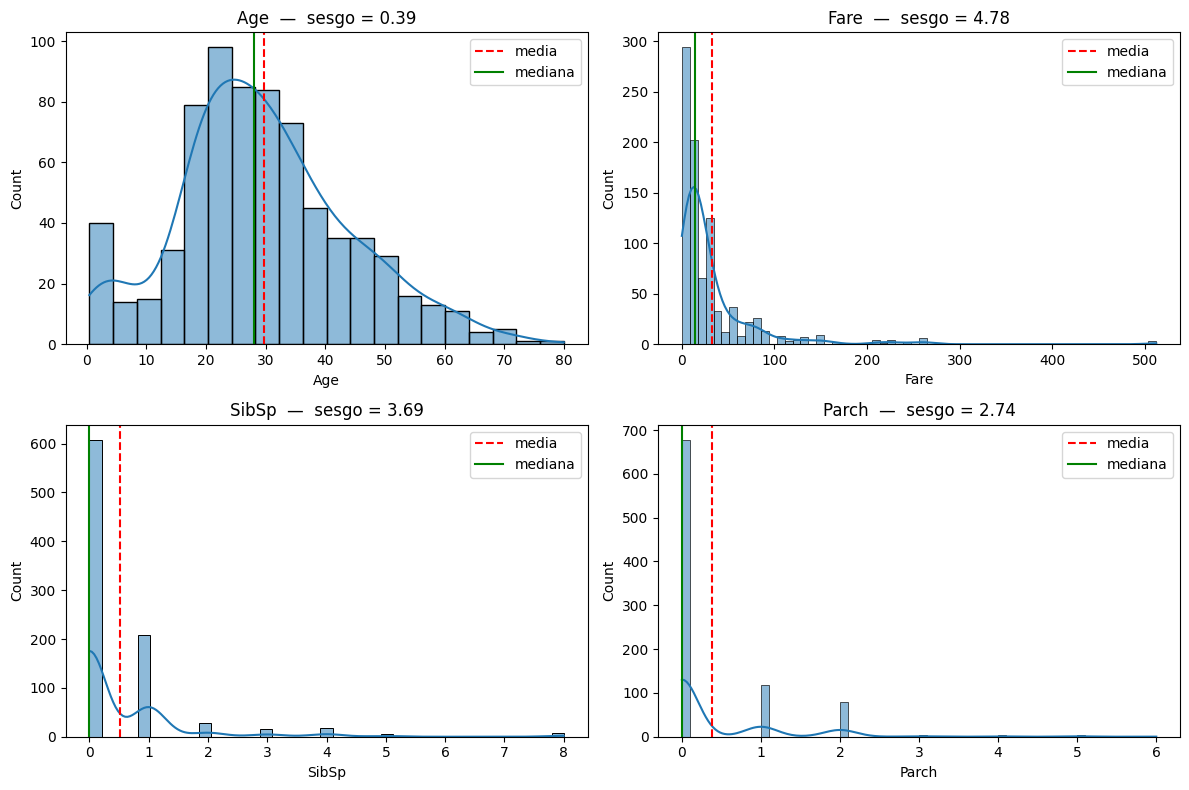

In [ ]:
# c) Visualizamos la distribucion de las variables continuas y su sesgo 
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew

# histograma + curva de densidad (KDE) de cada numerica, con su sesgo en el titulo
variables = ["Age", "Fare", "SibSp", "Parch"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))   # rejilla 2x2
axes = axes.ravel()                                # aplanar para iterar facil

for i, col in enumerate(variables):
    datos = df[col].dropna()                       # skew y el plot no admiten nulos
    s = skew(datos)                                # el numero del sesgo
    sns.histplot(datos, kde=True, ax=axes[i])      # histograma + curva suavizada
    axes[i].set_title(f"{col}  —  sesgo = {s:.2f}")
    axes[i].axvline(datos.mean(),   color="red",   linestyle="--", label="media")
    axes[i].axvline(datos.median(), color="green", linestyle="-",  label="mediana")
    axes[i].legend()

plt.tight_layout()
plt.show()

In [98]:
###### 👻 Comentarios sobre el dataset que se puede apreciar en la salida de las celdas anteriores

#La clave visual: dónde cae la media (roja) vs la mediana (verde)
#Antes de ir una por una, graba esta regla que aplica a las cuatro:
#La media (roja) siempre es jalada hacia la cola. Cuanto más lejos esté la roja de la verde, más sesgo hay. Si la roja está a la derecha de la verde → cola a la derecha → sesgo positivo.

#Age — sesgo 0.39 (casi simétrica) ✅
#Forma: una campana bastante pareja, centrada entre los 20–40. Sube, tiene su pico, y baja de forma más o menos equilibrada a ambos lados.
#Líneas: la roja (media ≈29.7) and la verde (mediana 28) están casi encimadas. Esa cercanía es la firma de la simetría.
#El escaloncito en 0–5: ese grupito de bebés/niños que ya conocemos (el famoso 0.42). No rompe la simetría general.
#Acción: ninguna. Sesgo bajo → no necesita transformación. Se usa tal cual.
#Fare — sesgo 4.78 (sesgo fuerte) 🔴
#Forma: el caso de libro de asimetría. Una montaña enorme pegada a la izquierda (casi todos pagaron tarifas bajas, 0–50) y una cola larguísima estirándose sola hasta 512. La mayoría amontonada abajo, poquísimos muy arriba.
#Líneas: aquí ves el efecto clarísimo — la roja (media ≈32) está claramente a la derecha de la verde (mediana ≈14). Esos pocos pasajes de 263–512 jalan el promedio hacia arriba, mientras la mediana (el pasajero "típico") se queda abajo. Que media y mediana estén tan separadas (32 vs 14) es sesgo puro.
#Acción: candidata clara a transformación log — si al final usas un modelo lineal. Con log, esa cola se comprime y la montaña se vuelve casi campana (viste que el sesgo bajaría de 4.78 a ~0.4). Para árboles, la dejarías igual.
#SibSp — sesgo 3.69 · Parch — sesgo 2.74 (sesgadas, pero OJO) ⚠️

#Estas dos son las importantes para afinar tu criterio, porque el número engaña un poco:

#Forma: no son curvas suaves — son barras separadas. Una barra gigante en 0 (la gran mayoría viajaba sin hermanos/cónyuge ni padres/hijos), y luego barritas cada vez más chicas en 1, 2, 3… El skew() calcula un número alto (3.69, 2.74) porque técnicamente hay cola a la derecha.
#El matiz clave: aunque el número de sesgo es alto, estas son DISCRETAS (conteos), no continuas — justo lo que clasificamos con la función anterior. En una variable de conteo, "aplicar log para corregir sesgo" no es la jugada natural. Aquí tiene más sentido:
#tratarlas como categóricas (0, 1, 2, "3+"…), o
#combinarlas en una feature nueva: FamilySize = SibSp + Parch + 1, o
#una bandera viaja_solo (1 si SibSp+Parch = 0).
#Por eso la función de tipos las marcó "no evaluar sesgo": el sesgo se les puede calcular, pero la acción que sugiere (log) no aplica bien a conteos. Su asimetría se maneja distinto.

#Esto confirma en vivo lo que discutimos: el sesgo solo dispara "transformación log" con sentido en las continuas (Fare). En las discretas (SibSp/Parch), el número alto es real pero la solución es otra.

#Resumen de las cuatro
#Variable	Sesgo	Forma	Lectura	Acción (plan)
#Age	0.39	campana pareja	simétrica	ninguna
#Fare	4.78	montaña izq. + cola larga	muy sesgada	log si modelo lineal
#SibSp	3.69	barra en 0 + colita	discreta sesgada	categórica / FamilySize
#Parch	2.74	barra en 0 + colita	discreta sesgada	categórica / FamilySize


In [ ]:
##### 🔶  F12 : Sesgos 
#####     Funcion : missingno — matrix, bar, heatmap, dendrogram)
#####     Objetivo : Visualizar graficamente los nulos y su correlación entre columnas

# 1) MATRIX - patron visual de huecos, fila por fila
# 2) BAR - completitud por columna (altura = % de datos presentes)
# 3) HEATMAP - ¿los nulos de una columna coinciden con los de otra?
# 4) DENDROGRAM - agrupa columnas por su patron de nulos

In [105]:
import missingno as msno
import matplotlib.pyplot as plt
df.shape

(891, 12)

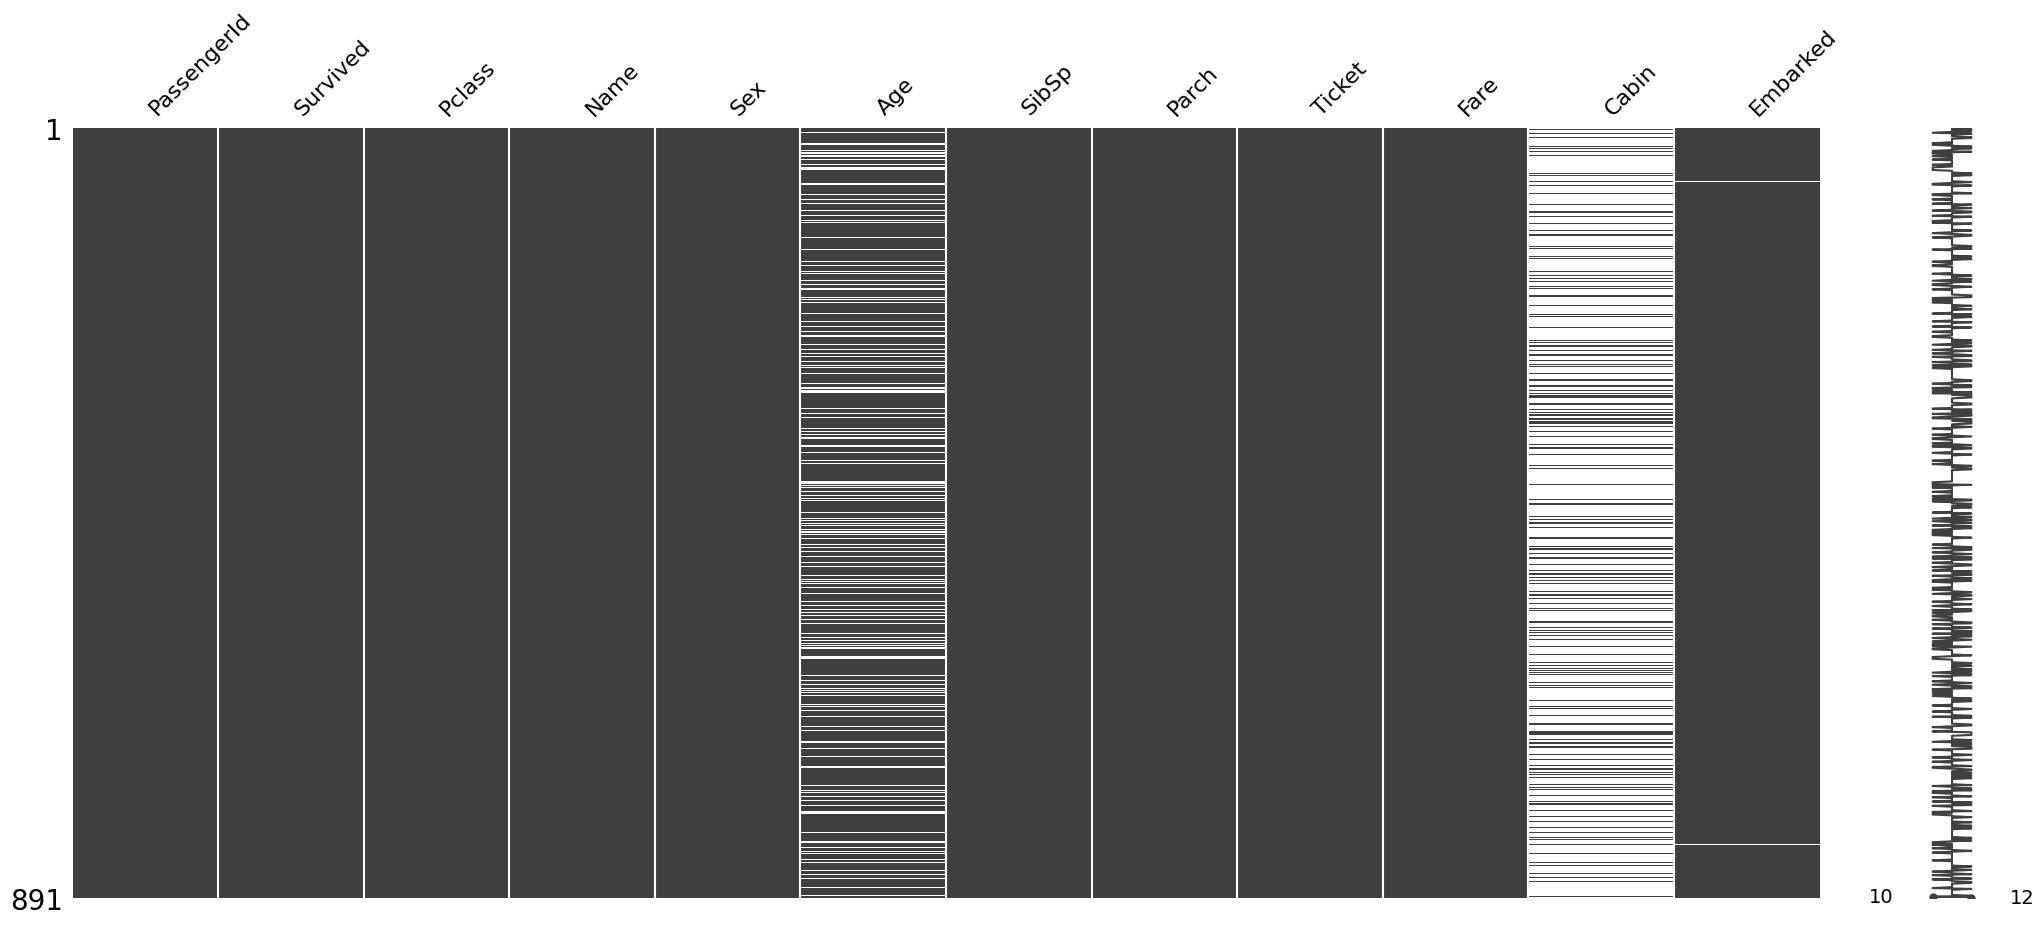

In [100]:
# 1) MATRIX - patron visual de huecos, fila por fila
msno.matrix(df)
plt.show()

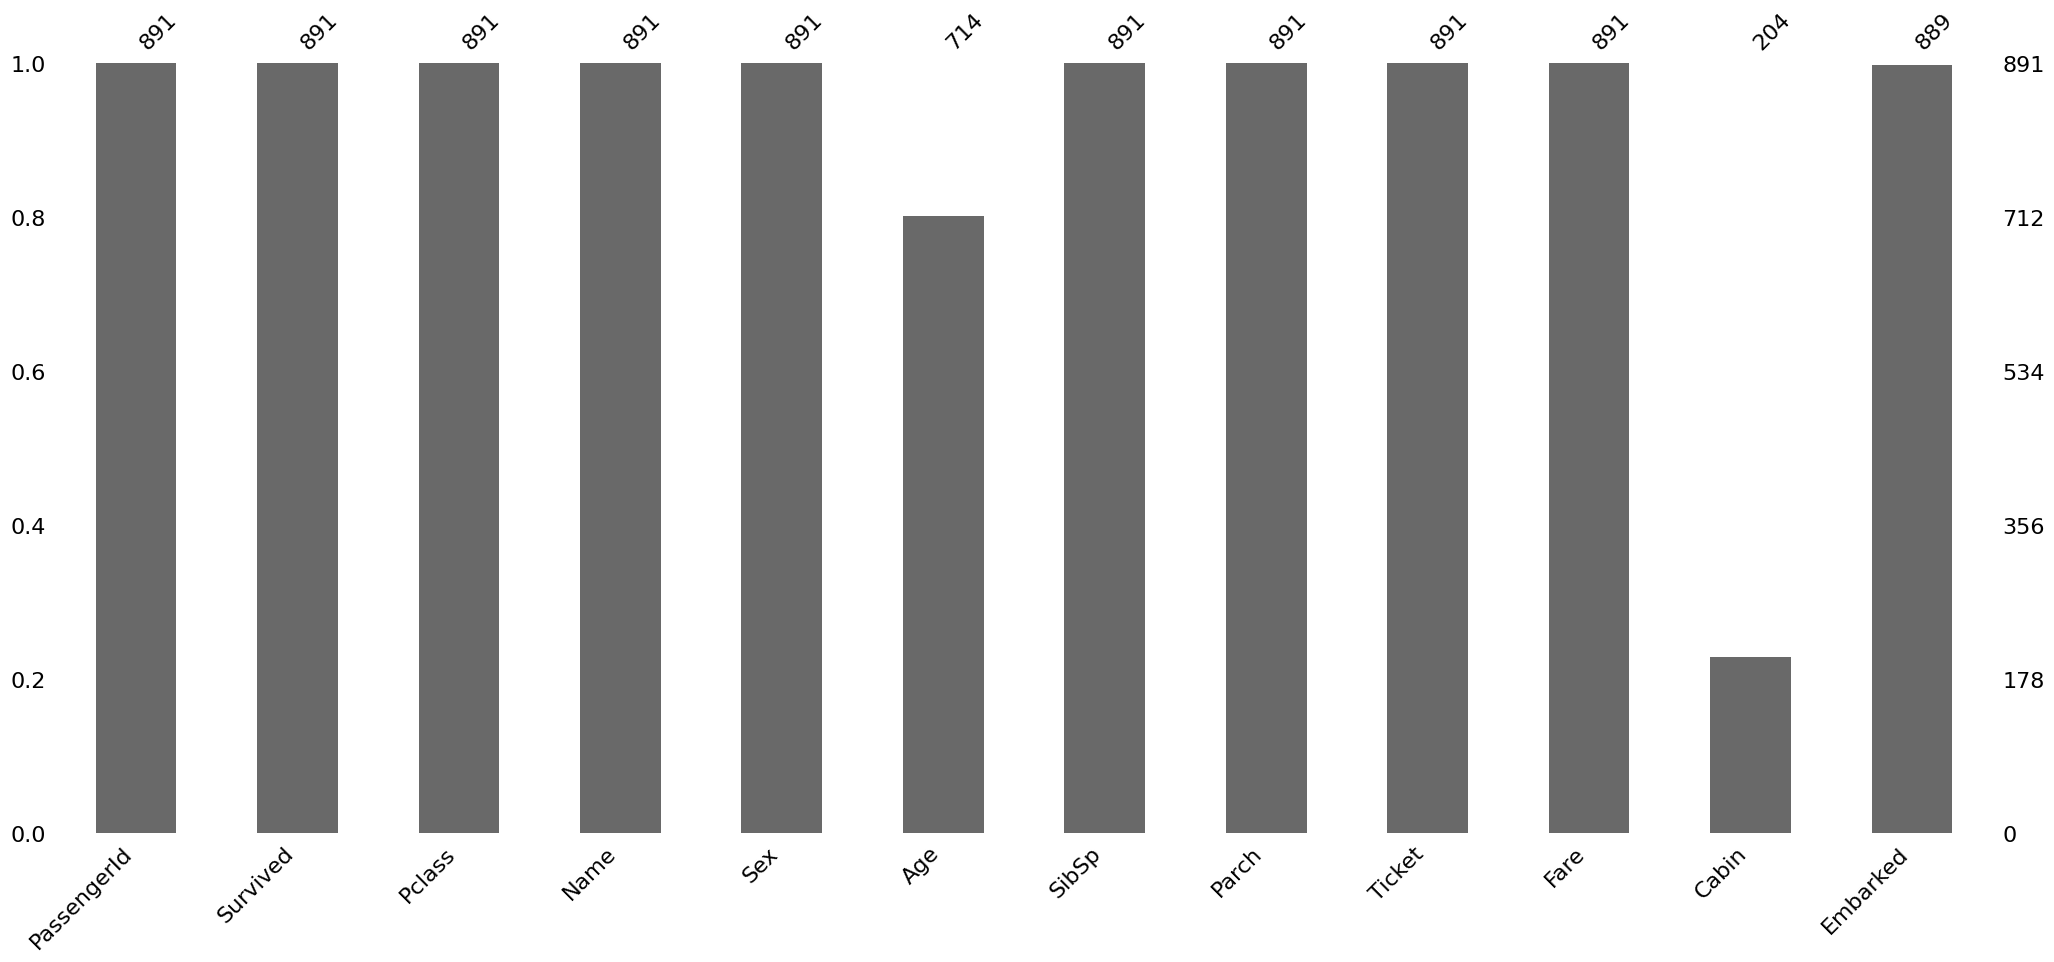

In [101]:
# 2) BAR - completitud por columna (altura = % de datos presentes)
msno.bar(df)
plt.show()

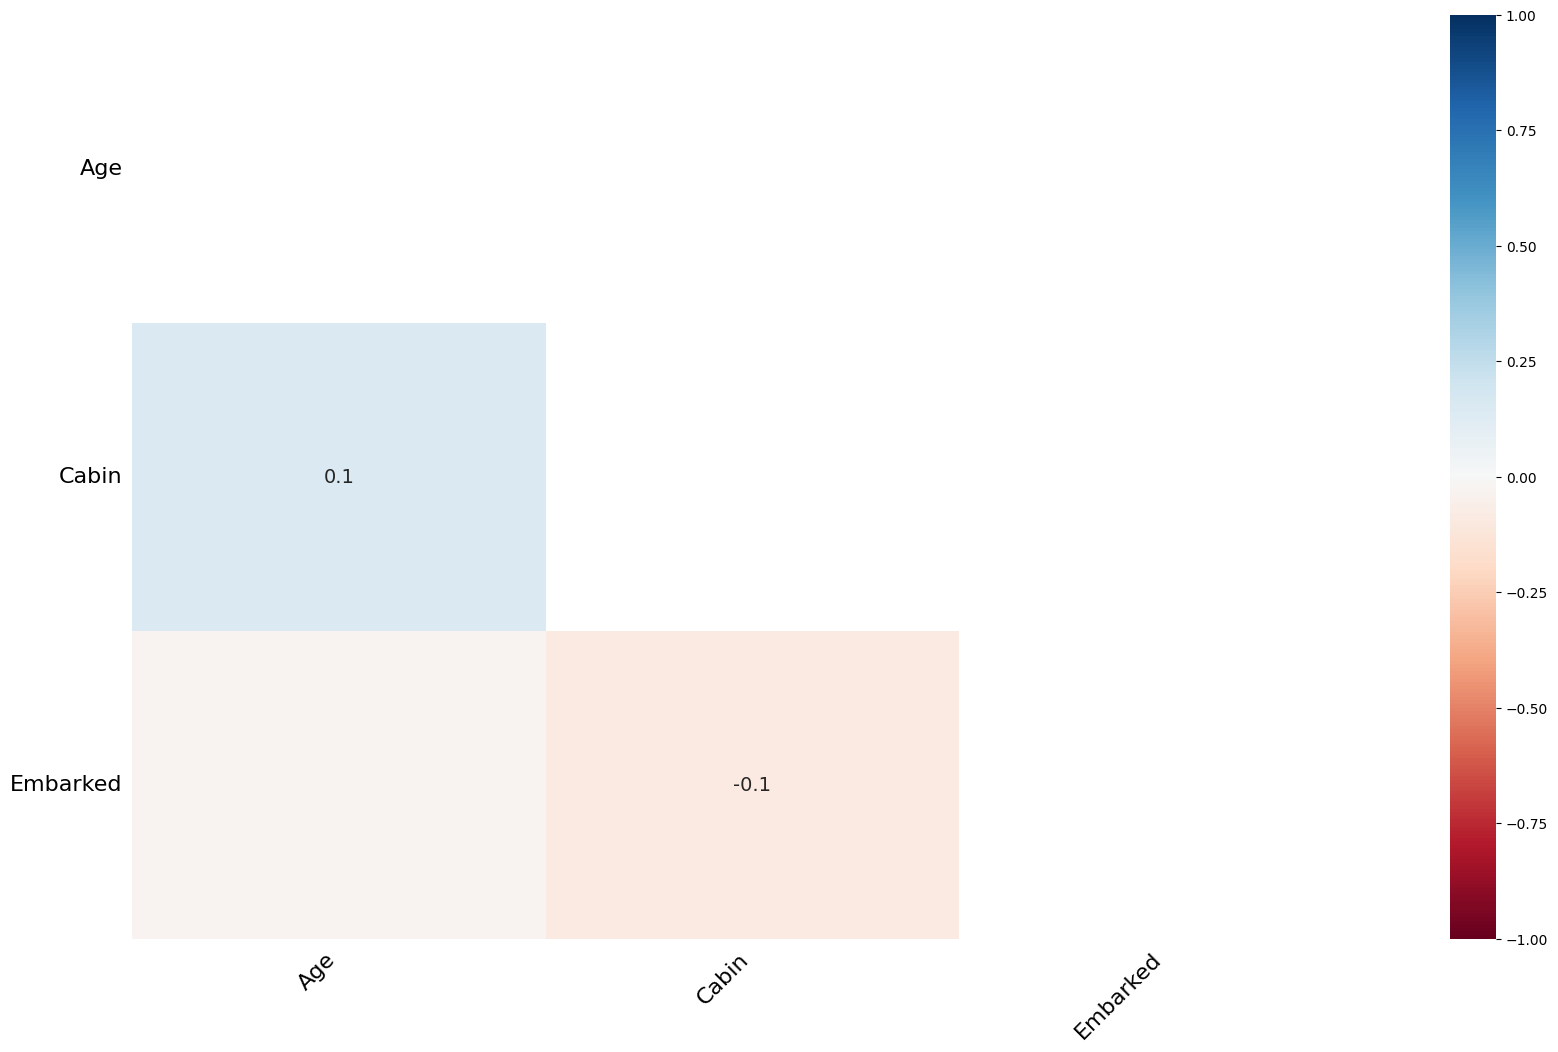

In [102]:
# 3) HEATMAP - ¿los nulos de una columna coinciden con los de otra?
msno.heatmap(df)
plt.show()

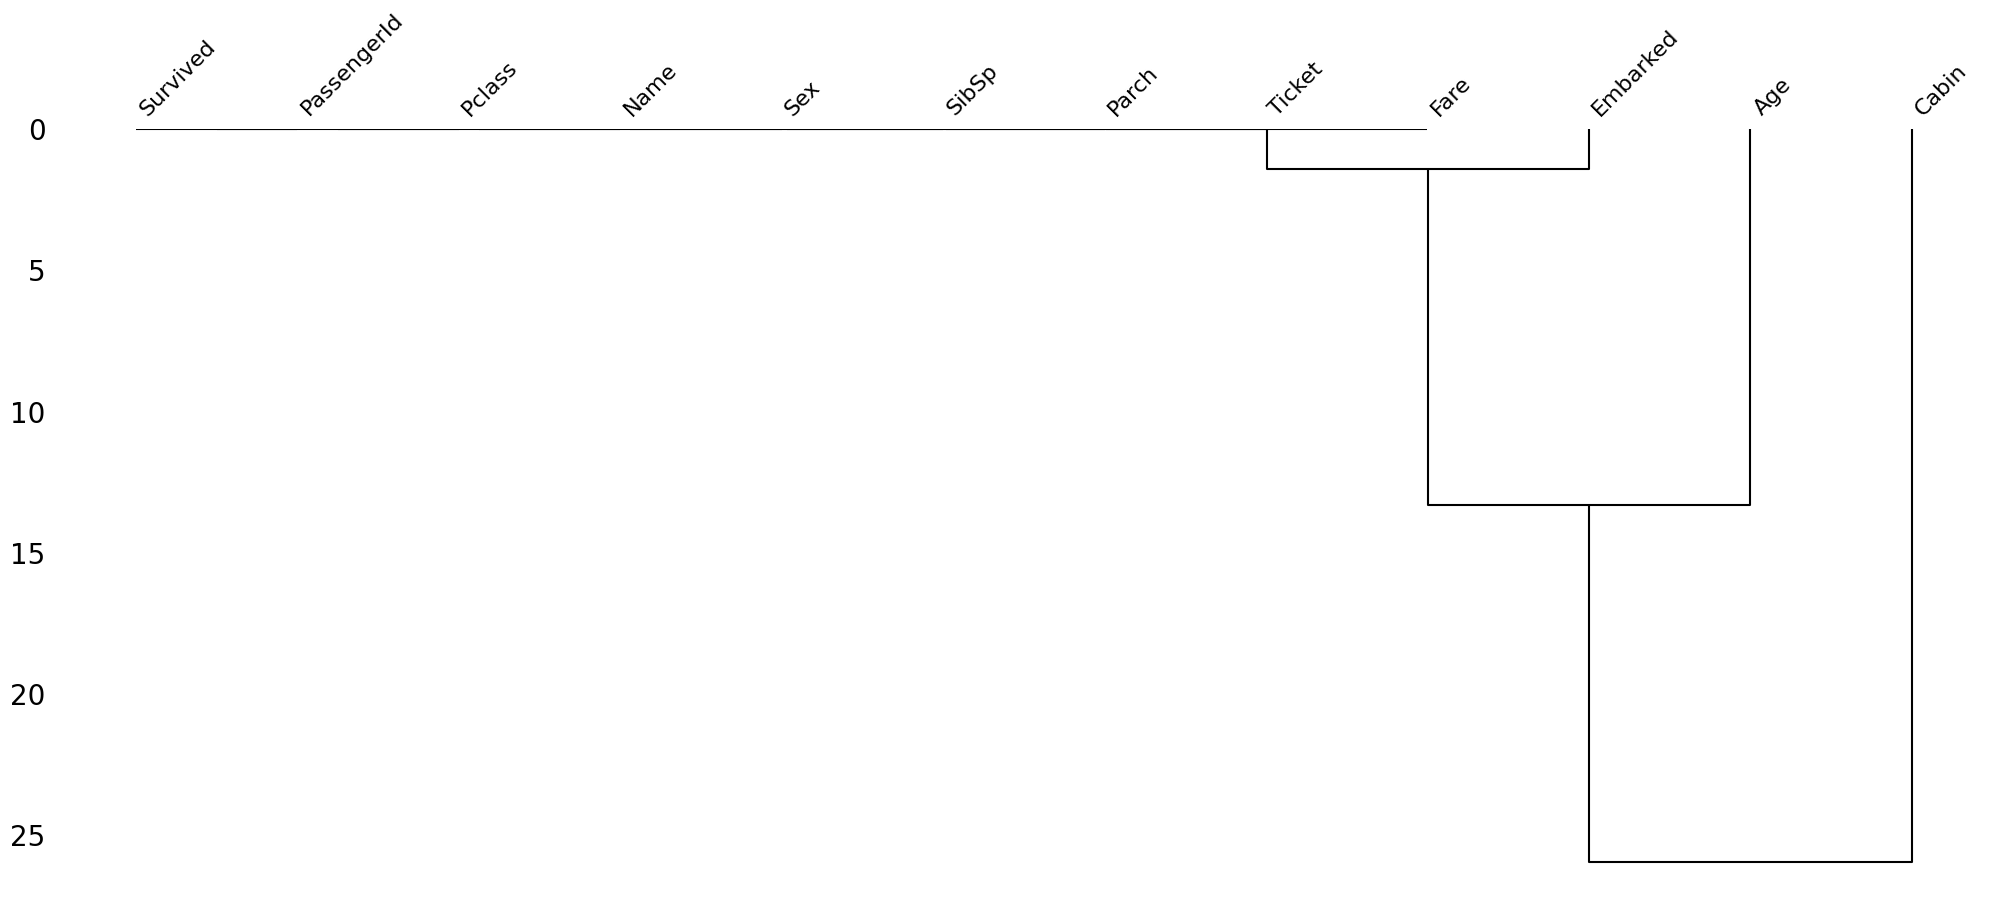

In [103]:
# 4) DENDROGRAM - agrupa columnas por su patron de nulos
msno.dendrogram(df)
plt.show()

In [ ]:
# 🚪 CONCLUSION > 🟢 Gate 2 — Validez y calidad
# (DRL Banda B · CRISP-DM Data Understanding · EDA Pasos 1-2)

# Pregunta: ¿El dato es fiel a la realidad? ¿Confio en el?
# Paso EDA / medicion: Paso 1 (estructura) + Paso 2 (calidad).
# Nucleo cuantitativo: % nulos por columna, # duplicados, # constantes,
#                      # valores imposibles, capping, patron de nulos, sesgo.

# Evidencia (funcion por funcion):
#   - Nulos  (isnull().sum()):   solo 3 columnas -> Cabin 77.1% (687), Age 19.9% (177),
#                                Embarked 0.2% (2). El target Survived: 0 nulos.
#   - Duplicados (duplicated()): 0 filas duplicadas completas; 0 PassengerId repetidos.
#   - Constantes (nunique()<=1): NINGUNA (varianza 0 no existe aqui).
#   - Imposibles (describe()):   NINGUNO sin explicar. Age 0.42 = bebe real (7 <1 anio);
#                                Fare 0 = cortesia/tripulacion (15, plausible);
#                                Fare 512 = outlier real, no error.
#   - Dominio:                   Survived{0,1}, Pclass{1,2,3}, Sex{m,f}, Embarked{S,C,Q}
#                                -> 0 valores fuera de dominio.
#   - Higiene (value_counts):    sin typos, espacios ni mayusculas inconsistentes.
#   - Capping (value_counts):    NO hay. Picos de frecuencia en el centro del rango
#                                (Fare 8.05, Age 24), no en los bordes.
#   - Patron de nulos (missingno): huecos independientes entre si (heatmap ~0);
#                                Cabin cuelga sola en el dendrogram -> sin fallo por bloque.
#   - Sesgo (skew, solo continuas): Age 0.39 (simetrica, sin accion);
#                                Fare 4.78 (sesgo fuerte -> candidata a log si modelo lineal).

# Hallazgo clave: los nulos NO son aleatorios (MNAR). La ausencia de Cabin es
#   informativa -> Cabin presente 66.7% sobrevive vs ausente 30.0% (proxy de 1a clase).

# Plan de limpieza (se ANOTA aqui, se EJECUTA en Data Preparation, no en el EDA):
#   - Cabin (77%):    NO imputar (seria inventar) -> convertir en bandera tiene_cabina (0/1).
#   - Age (20%):      imputar POR GRUPO (Pclass/titulo), no con media global.
#   - Embarked (0.2%): imputar con la moda (S).
#   - Fare:           candidata a transformacion log (condicional a usar modelo lineal).

# Matiz: Cabin al 77% de nulos es alto, pero esta caracterizado y con plan claro
#   (se vuelve senal, no se pelea). No arrastra a CONDITIONAL porque la integridad
#   del dato en si es solida: 0 duplicados, 0 constantes, 0 imposibles, 0 fuera de dominio.

# Veredicto: GO. Dato fiel a la realidad: nulos cuantificados, entendidos y con plan;
#   sin duplicados, sin constantes, sin valores imposibles ni fuera de dominio.
# Condicion / dueño / plazo: ejecutar el plan de limpieza en la fase de preparacion. Cerrado.

# Conclusion en una linea: el dato es confiable; los unicos huecos (Cabin/Age/Embarked)
#   estan caracterizados, son informativos y tienen plan de tratamiento definido.

# Gate 3 — Ground truth etiquetado y de calidad - Integridad de Datos y Etiqueta Target



In [ ]:
##### ▶️ Objetivo :
# el objetivo del Gate 3 es confirmar que tienes ground truth etiquetado y de calidad 
#   — en el Titanic es la columna Survived (0/1, completa, histórica); 
#   - en el robot sería el cruce telemetría × órdenes de mantenimiento para saber cuándo falló. 
#      Sin esa etiqueta, no hay aprendizaje supervisado posible.
#
#   FUNCIONES QUE SE PUEDEN USAR 
#       🔶  F1 : Balance de datos (salidas)  |   df['y'].value_counts(normalize=True)   |   Cuando el Target es binario
#       🔶  F2 : Distribucion de Target      |  hist() / kdeplot()   |   Cuando el Target es continua
#                
#   Las funciones hist/kdeplot/describe sirven para estudiar la forma de una distribución continua — tienen sentido si el target fuera un número medible (regresión/RUL), pero en un binario de 2 valores no hay "forma" que estudiar, solo 2 barras.
#
# ESTE PUNTO SE TRATA SOBRE LA VARIABLE TARGET. 
#  +  ¿la cosa que quiero predecir (Survived) está bien?".
#
# RESPONDE ESTAS PREGUNTAS
# ¿Existe la etiqueta? → sí, columna Survived. ✔
# ¿Balance? → 62/38, desbalance leve. ✔ (ya lo corriste)
# ¿Capado / nulos? → Survived ∈ {0,1}, 0 nulos. ✔
# ¿Construible? → no hace falta, viene dada. ✔
# 
# Verificar que tienes la "respuesta correcta" (el ground truth) para poder aprender de ella. 
# Un modelo supervisado aprende de ejemplos etiquetados: 
#   le muestras casos donde ya sabes el resultado, y él aprende el patrón. 
#   Si no tienes esas etiquetas, o son de mala calidad, no hay nada que aprender 
#   — no importa cuán bueno sea el dato de entrada.
# 
# 👁️ Ver document de Gate3_groundTruth.md





In [110]:
##### 🔶  F1 : Balance de datos (salidas) 
#####     Funcion : df['y'].value_counts(normalize=True)
#####     Objetivo : Validar el punto clave del balance de clases es qué tan disparejo está, porque eso cambia la estrategia:

# balance de clases: ¿cuantos sobrevivieron vs murieron?
df["Survived"].value_counts()                    # conteo absoluto


Survived
0    549
1    342
Name: count, dtype: int64

In [107]:
df["Survived"].value_counts(normalize=True)      # en proporcion (%)

Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

In [ ]:
###### 👻 Comentarios sobre el dataset que se puede apreciar en la salida de las celdas anteriores
# 
# Cómo se lee este balance (la escala)

# El punto clave del balance de clases es qué tan disparejo está, porque eso cambia la estrategia:

# Proporción	Tipo	Qué implica
# ------------------------------------------------------------------------------
# ~50/50	perfectamente balanceado	ideal, sin complicaciones
#  60/40 – 70/30	desbalance leve ← tu caso (62/38)	manejable, sin técnicas especiales
#  80/20 – 90/10	desbalance moderado	ya requiere cuidado (métricas, quizá resampling)
#  95/5 o peor	desbalance severo	cambia toda la estrategia (métricas especiales, umbral, resampling):

# Por qué el balance importa tanto (conexión con otros Gates)

#  Este número no es decorativo — dispara tres cosas:

# 1. Descarta el "accuracy engañoso". 
#    Tu guía advierte que un 95/5 hace que "predecir siempre la clase mayoritaria" dé 95% de accuracy sin haber aprendido nada. Con tu 62/38, ese truco solo daría 61.6% — un piso bajito y honesto. Eso significa que accuracy sí es una métrica válida aquí (no te engaña como lo haría con desbalance severo). Aun así, mediremos también F1/precision/recall en el Gate 7.

# 2. Define el baseline ingenuo (Gate 7). 
#    Ya tienes tu piso: cualquier modelo que hagas debe superar el 61.6% (que es lo que da "predecir que todos mueren"). Si tu modelo elegante saca 62%, no aprendió nada. Ese 61.6% es la vara a superar.

# 3. Cierra el Gate 6 provisional.
#    Recuerda que el Gate 6 (suficiencia) estaba en amarillo esperando el balance. Ahora sabemos: 891 filas con 342 casos de la clase minoritaria (sobrevivientes) → muestra más que suficiente de ambas clases para entrenar y validar. Gate 6 se puede subir a GO.

# Gate 3 → 🟢 GO — ficha nueva completa, con los 4 chequeos 
# sobre Survived (existe, 891 etiquetados, timestamp N/A, balance 62/38, 
# sin capping ni nulos) y la consecuencia clave: target binario → clasificación.
